In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
df = pd.read_excel("data_full.xlsx", index_col=0)

In [3]:
df.head()

,Model,Input No,Output,QAL-Score,QAN-Score,commandLen,num_words,num_chars,num_lines,word_entropy,char_entropy,capitalization_ratio
0,GPT4o,1,uid=1000(user1) gid=1000(user1) groups=1000(us...,1.0,0,50,12,50,1,2.396241,3.670490,0.000000
1,GPT4o,2,total 32\ndrwxr-xr-x 4 user1 user1 4096 Nov 2...,1.0,0,406,89,406,9,4.325948,4.423147,0.121019
2,GPT4o,3,/home\ntotal 12\ndrwxr-xr-x 3 root root 409...,1.0,1,157,30,157,5,3.781076,4.266204,0.044776
3,GPT4o,4,NaN,1.0,0,0,0,0,1,0.000000,0.000000,0.000000
4,GPT4o,5,user1,0.0,1,5,1,5,1,0.000000,2.321928,0.000000


In [4]:
for model in df["Model"].unique():
    print(model)
    print(df[df["Model"]==model][["num_words","char_entropy","QAL-Score", "QAN-Score"]].mean())

GPT4o
num_words       42.43750
char_entropy     3.40558
QAL-Score        0.87500
QAN-Score        0.31250
dtype: float64
GPT4omini
num_words       21.250000
char_entropy     3.235161
QAL-Score        0.750000
QAN-Score        0.375000
dtype: float64
Gemini1.5Flash
num_words       13.000000
char_entropy     3.994195
QAL-Score        0.000000
QAN-Score        0.000000
dtype: float64
SonarPro
num_words       103.312500
char_entropy      4.602911
QAL-Score         0.687500
QAN-Score         0.125000
dtype: float64
Sonar
num_words       82.750000
char_entropy     4.595762
QAL-Score        0.687500
QAN-Score        0.187500
dtype: float64
DeepSeekR1
num_words       149.687500
char_entropy      4.575831
QAL-Score         0.437500
QAN-Score         0.062500
dtype: float64
Phi4
num_words       46.312500
char_entropy     4.555412
QAL-Score        0.312500
QAN-Score        0.312500
dtype: float64
Llama3-8
num_words       36.250000
char_entropy     4.363413
QAL-Score        0.250000
QAN-Score     

In [5]:
for model in df["Model"].unique():
    print(model)
    print(df[df["Model"]==model]["QAL-Score"].mean())

GPT4o
0.875
GPT4omini
0.75
Gemini1.5Flash
0.0
SonarPro
0.6875
Sonar
0.6875
DeepSeekR1
0.4375
Phi4
0.3125
Llama3-8
0.25
Llama3.1-8
0.15625
Llama3.2-3
0.0625
Llama3.2-1
0.0625
Llama3.3
0.71875


In [6]:
df = df.drop(df[df["Model"] == "Sonar"].index, ).reset_index(drop=True)
df = df.drop(df[df["Model"] == "SonarPro"].index).reset_index(drop=True)

In [7]:
df[df["Model"] == "Sonar"]

,Model,Input No,Output,QAL-Score,QAN-Score,commandLen,num_words,num_chars,num_lines,word_entropy,char_entropy,capitalization_ratio


In [8]:
scores = {
    "QAL": {},
    "QAN": {}
}
for model in df["Model"].unique():
    # skip Sonar models, as they actually are not that relevant
    # under the hood it uses existing other models anyways
    scores["QAL"][model] = round(df[df["Model"]==model]["QAL-Score"].mean(),2)
    scores["QAN"][model] = round(df[df["Model"]==model]["QAN-Score"].mean(),2)

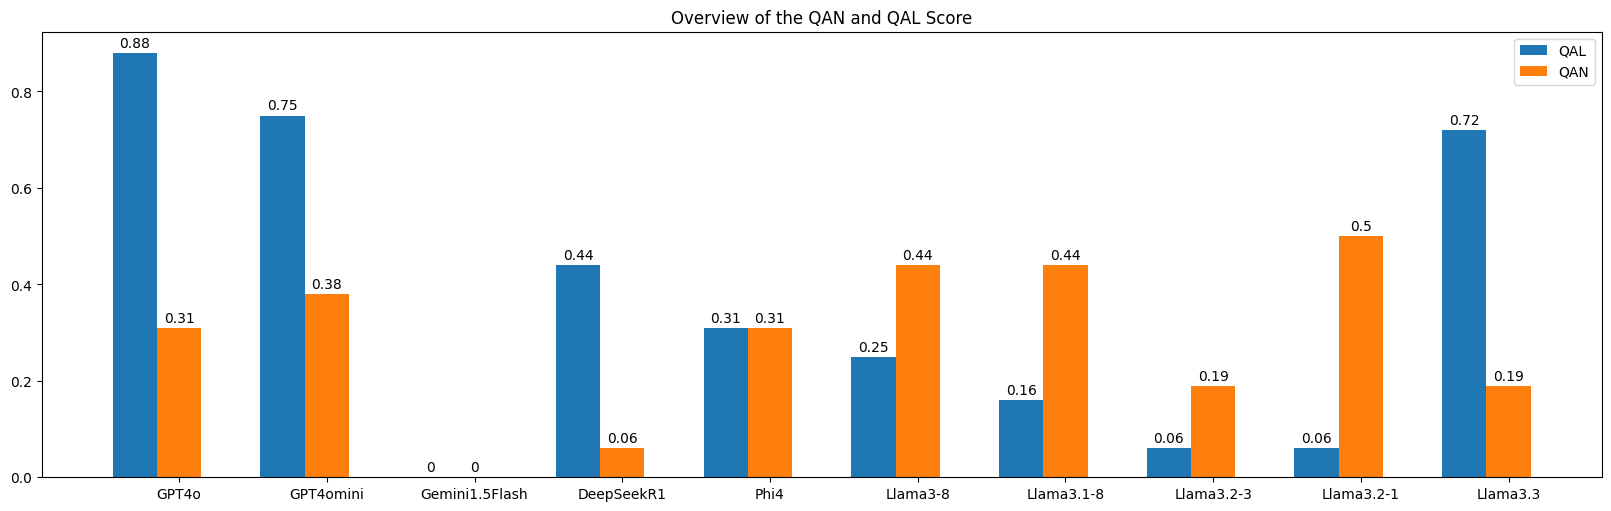

In [9]:
fig, ax = plt.subplots(figsize=(16,5), layout='constrained')

width = 0.3
multiplier = 0

for score, vals in scores.items():
    offset = width * multiplier
    x = np.arange(len(vals.keys()))
    rects = ax.bar(x + offset, vals.values(), width, label=score)
    ax.bar_label(rects, padding=2)
    multiplier += 1

ax.legend()
ax.set_xticks(x + width, df["Model"].unique())
ax.set_title("Overview of the QAN and QAL Score")
plt.show()


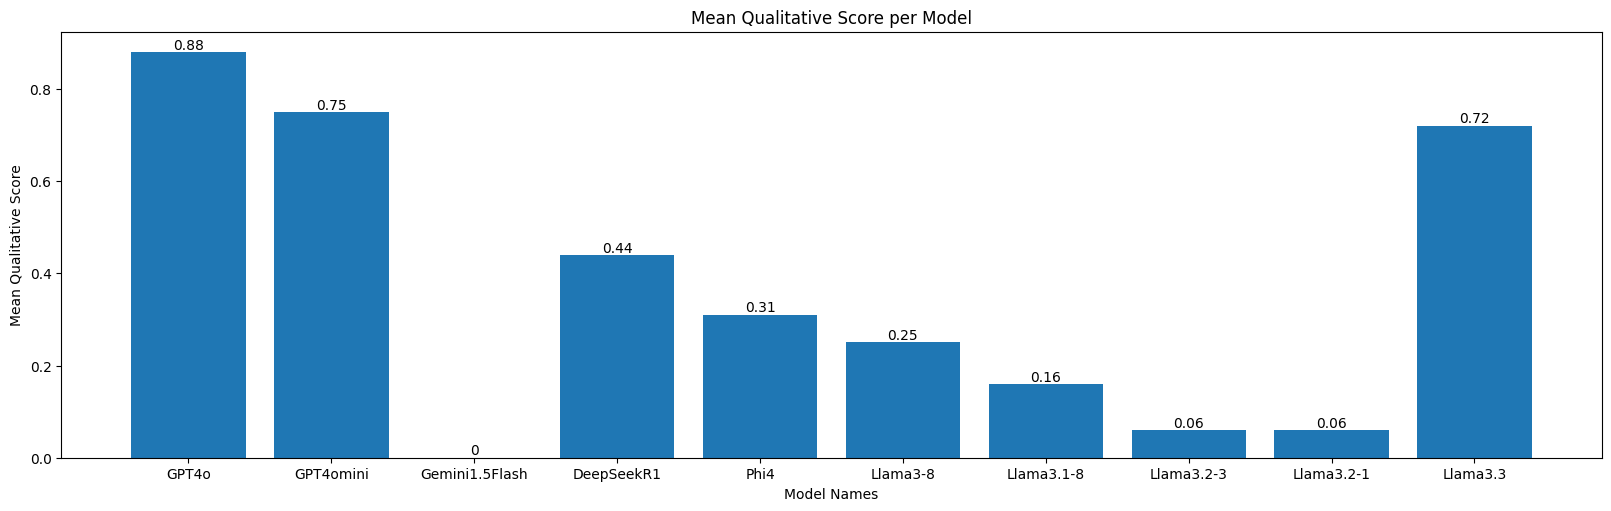

In [10]:
fig, ax = plt.subplots(figsize=(16,5), layout='constrained')

p = ax.bar(scores["QAL"].keys(), scores["QAL"].values())
ax.bar_label(p)


ax.set_title("Mean Qualitative Score per Model")
ax.set_xlabel("Model Names")
ax.set_ylabel("Mean Qualitative Score")
plt.savefig("QAL_scores.png", dpi=300)
plt.show()

In [11]:
speed = {
    "GPT4o":2,
    "GPT4omini":1,
    "Gemini1.5Flash":1,
    "DeepSeekR1":3,
    "Phi4":2,
    "Llama3-8":1,
    "Llama3.1-8":1,
    "Llama3.2-3":1,
    "Llama3.2-1":1,
    "Llama3.3":2,
}

In [12]:
pen_scores = {}

for model, val in scores["QAL"].items():
    penalty = (1 - (np.log(speed[model]) + 1) / np.log(20))
    pen = round(val * penalty,2)
    print(f"{model}: {pen} ({penalty})")
    pen_scores[model] = pen

GPT4o: 0.38 (0.4348135861449067)
GPT4omini: 0.5 (0.666191799304666)
Gemini1.5Flash: 0.0 (0.666191799304666)
DeepSeekR1: 0.13 (0.29946600796258116)
Phi4: 0.13 (0.4348135861449067)
Llama3-8: 0.17 (0.666191799304666)
Llama3.1-8: 0.11 (0.666191799304666)
Llama3.2-3: 0.04 (0.666191799304666)
Llama3.2-1: 0.04 (0.666191799304666)
Llama3.3: 0.31 (0.4348135861449067)


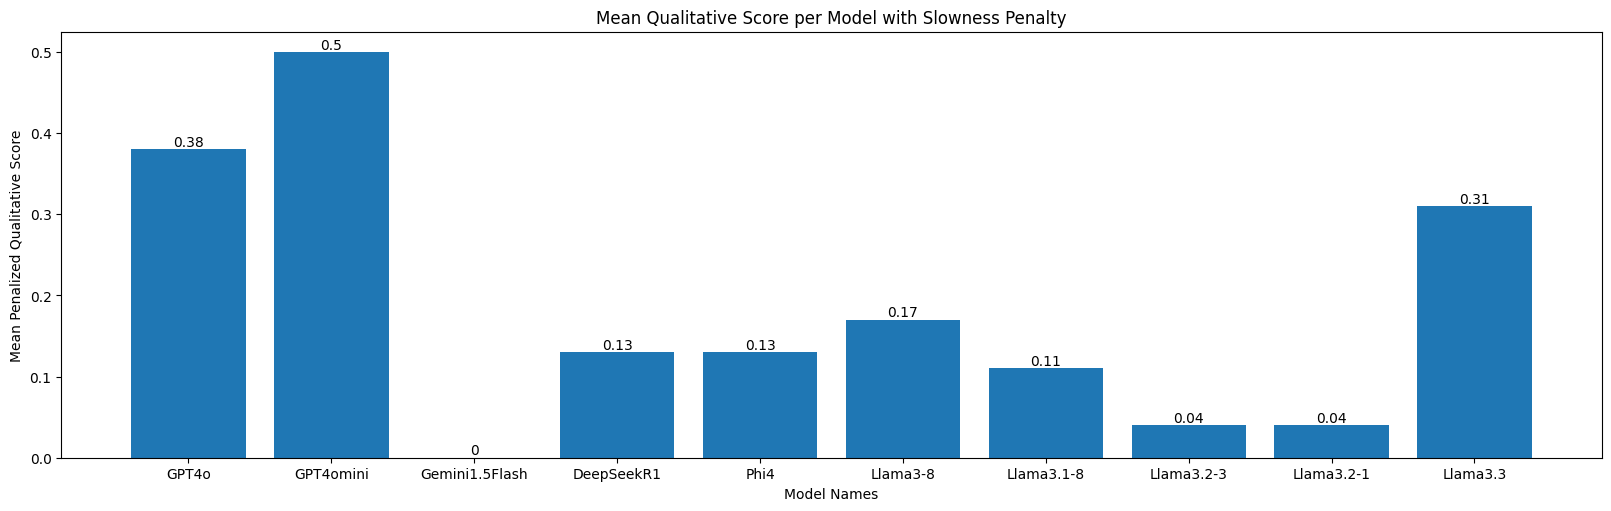

In [13]:
fig, ax = plt.subplots(figsize=(16,5), layout='constrained')

p = ax.bar(pen_scores.keys(), pen_scores.values(), label="Penalized QAL")
ax.bar_label(p)

ax.set_title("Mean Qualitative Score per Model with Slowness Penalty")
ax.set_xlabel("Model Names")
ax.set_ylabel("Mean Penalized Qualitative Score")
plt.savefig("QAL_slowness.png", dpi=300)
plt.show()